In [4]:
from smalldiffusion.model_unet import myUnet
from smalldiffusion.model import Scaled
from smalldiffusion.wavedata import npyDataResized
from torch.utils.data import DataLoader
from torch_ema import ExponentialMovingAverage as EMA
import torch
import numpy as np
import os
from torchvision import transforms as tf
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
casepath = '../run/global/log1p/loglinear3/'
ckpt = 'ckpt_12.pt'

In [8]:
train_file_path = '/global/homes/j/jiarongw/scratch_folder/wave_data/train_global/'
test_file_path = '/global/homes/j/jiarongw/scratch_folder/wave_data/test_global/'
test_file_names = [('wave_200804', 'forcing_200804')]
stats_file = os.path.join(train_file_path, 'stats.npz')
stats = np.load(stats_file)
meanx, stdx = stats['meanx'], stats['stdx']
meanf, stdf = stats['meanf'], stats['stdf']

### Load model 
model = Scaled(myUnet)(in_dim=320, in_ch=4, out_ch=4, ch=128, precond_ch=3, 
                       scale=(torch.tensor([0.,0.,0.,0.]), torch.tensor([0.,0.,0.,0.]),
                              torch.tensor([0.,0.,0.,]), torch.tensor([0.,0.,0.,])),
                       ch_mult=(1, 2, 2), attn_resolutions=(16,))
ema = EMA(model.parameters(), decay=0.999)
ckpt = torch.load(casepath + ckpt, map_location="cpu")
model.load_state_dict(ckpt["model"])
ema.load_state_dict(ckpt["ema"])

### Construct test dataset
test_file_list = [(os.path.join(test_file_path, f'{x}.npy'), 
                   os.path.join(test_file_path, f'{f}.npy')) for x, f in test_file_names]
test = npyDataResized(
    test_file_list,
    resize_x=(320,320), resize_f=(320,320), 
    landmaskname=os.path.join(test_file_path, 'mask.npy'),
    use_icymask=True,
    compute_stats=False,
    meanx=meanx, stdx=stdx, meanf=meanf, stdf=stdf
)

In [ ]:
import torch
import numpy as np

class LossByNoiseLevel:
    def __init__(self, num_timesteps, num_bins=10):
        self.num_bins = num_bins
        self.num_timesteps = num_timesteps
        self.bin_size = num_timesteps // num_bins
        self.reset()
    
    def reset(self):
        self.bin_losses = [[] for _ in range(self.num_bins)]
    
    def update(self, losses, timesteps):
        """
        losses: tensor of shape (batch_size,)
        timesteps: tensor of shape (batch_size,)
        """
        bin_indices = timesteps // self.bin_size
        # Clamp to handle edge case where timestep == num_timesteps
        bin_indices = torch.clamp(bin_indices, 0, self.num_bins - 1)
        
        for loss, bin_idx in zip(losses, bin_indices):
            self.bin_losses[bin_idx.item()].append(loss.item())
    
    def compute_means(self):
        means = []
        for bin_losses in self.bin_losses:
            if len(bin_losses) > 0:
                means.append(np.mean(bin_losses))
            else:
                means.append(float('nan'))
        return means
    
    def print_summary(self):
        means = self.compute_means()
        for i, mean in enumerate(means):
            t_start = i * self.bin_size
            t_end = (i + 1) * self.bin_size
            print(f"Timesteps {t_start}-{t_end}: {mean:.4f}")

In [26]:
from smalldiffusion.diffusion import ScheduleLogLinear, samples
schedule = ScheduleLogLinear(sigma_min=0.001, sigma_max=80, N=200)
from accelerate import Accelerator
a = Accelerator()
loader_test = DataLoader(test, batch_size=1, shuffle=True)
model, loader = a.prepare(model, loader_test)
ema.to(a.device)
model.eval()

myUnetScaled(
  (sig_embed): SigmaEmbedderSinCos(
    (mlp): Sequential(
      (0): Linear(in_features=2, out_features=512, bias=True)
      (1): SiLU()
      (2): Linear(in_features=512, out_features=512, bias=True)
    )
  )
  (conv_in): Conv2d(7, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (downs): ModuleList(
    (0): Module(
      (blocks): ModuleList(
        (0-1): 2 x CondSequential(
          (0): ResnetBlock(
            (layer1): Sequential(
              (0): GroupNorm(32, 128, eps=1e-06, affine=True)
              (1): SiLU()
              (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            )
            (temb_proj): Sequential(
              (0): SiLU()
              (1): Linear(in_features=512, out_features=128, bias=True)
            )
            (layer2): Sequential(
              (0): GroupNorm(32, 128, eps=1e-06, affine=True)
              (1): SiLU()
              (2): Dropout(p=0.1, inplace=False)
              (3): C

In [27]:
n_ensem = 10

loader_iter = iter(loader_test) 
x, f, mask = next(loader_iter)

x0_ensem = []
with ema.average_parameters():
    for i in range(0, n_ensem):
        print(f'Generate sample {i} ...')
        *xt, x0 = samples(model, schedule.sample_sigmas(100), gam=1, batchsize=1,
                          accelerator=a, cond=f, mask=mask)
        x_ = test.invert_x(x0[0])
        x_ = x_ * tf.Resize((320,720))(mask[0].to(x_))
        x0_ensem.append(x_.cpu().numpy())

x_truth = test.invert_x(x[0]) * tf.Resize((320,720))(mask[0].to(x))
x_truth = x_truth.cpu().numpy()
f_ = test.invert_f(f[0]).cpu().numpy()
x0_ensem = np.array(x0_ensem)

Generate sample 0 ...
Generate sample 1 ...
Generate sample 2 ...
Generate sample 3 ...
Generate sample 4 ...
Generate sample 5 ...
Generate sample 6 ...
Generate sample 7 ...
Generate sample 8 ...
Generate sample 9 ...


### Plot two samples

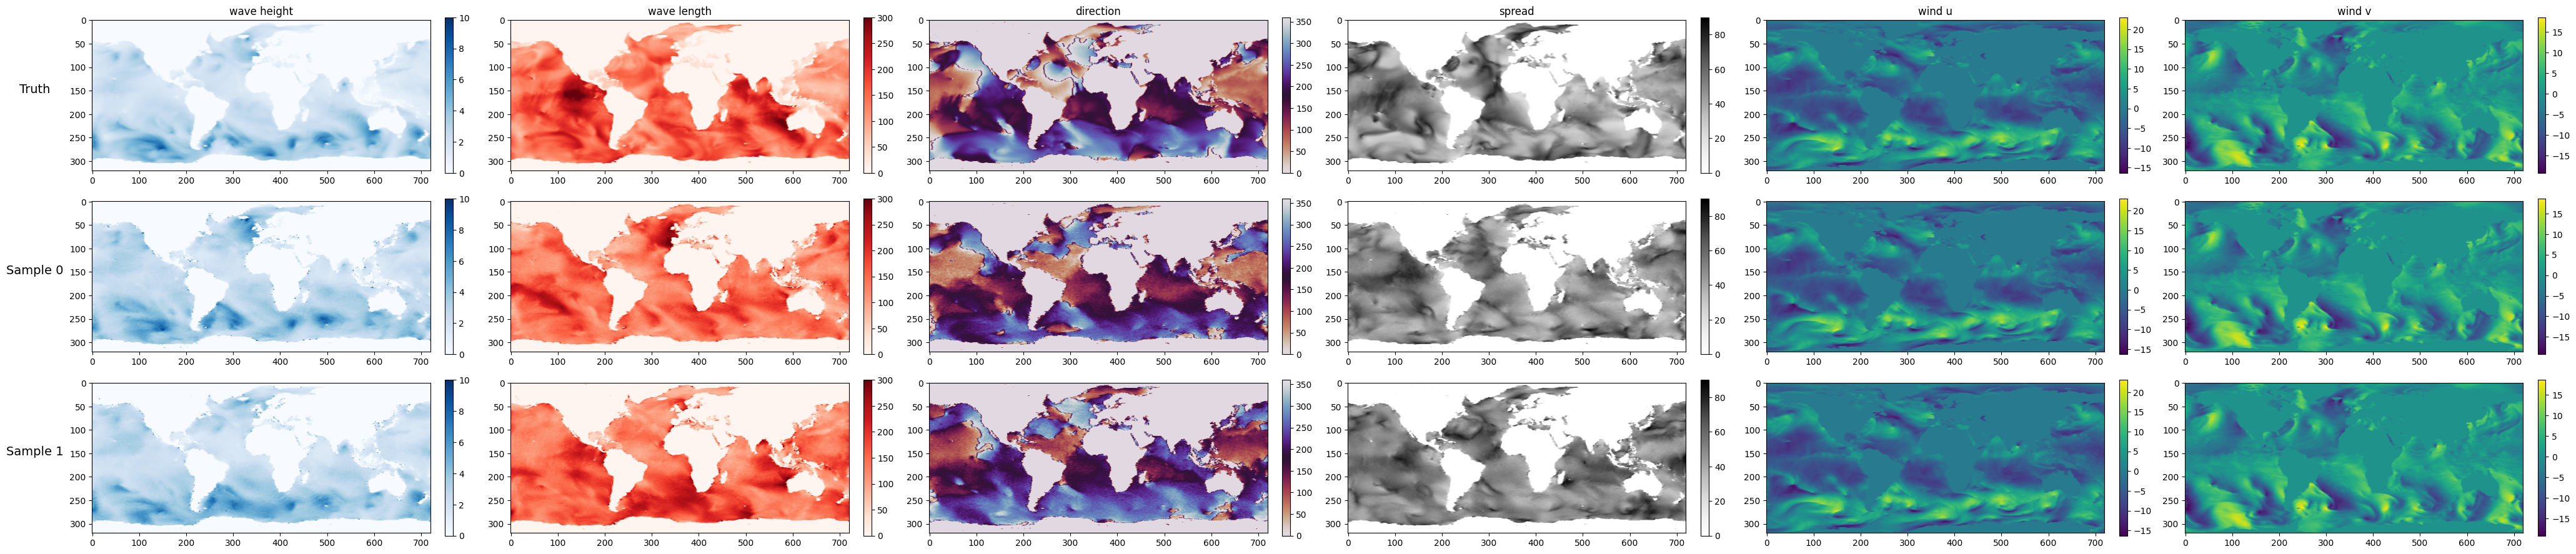

In [28]:
from waveutils import plot_sample
fig = plot_sample(x_truth[:,::-1], x0_ensem[:2,:,::-1], f_[:,::-1])

### Plot mean and variance

In [29]:
mean = x0_ensem[:20].mean(axis=0)
std = x0_ensem[:20].std(axis=0)

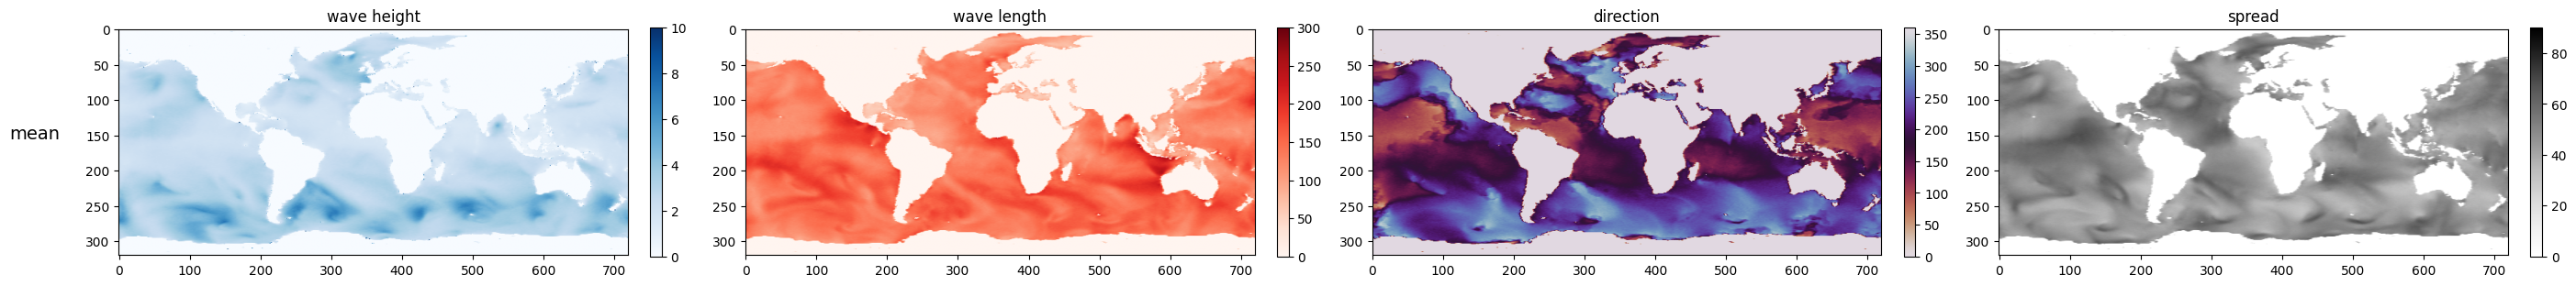

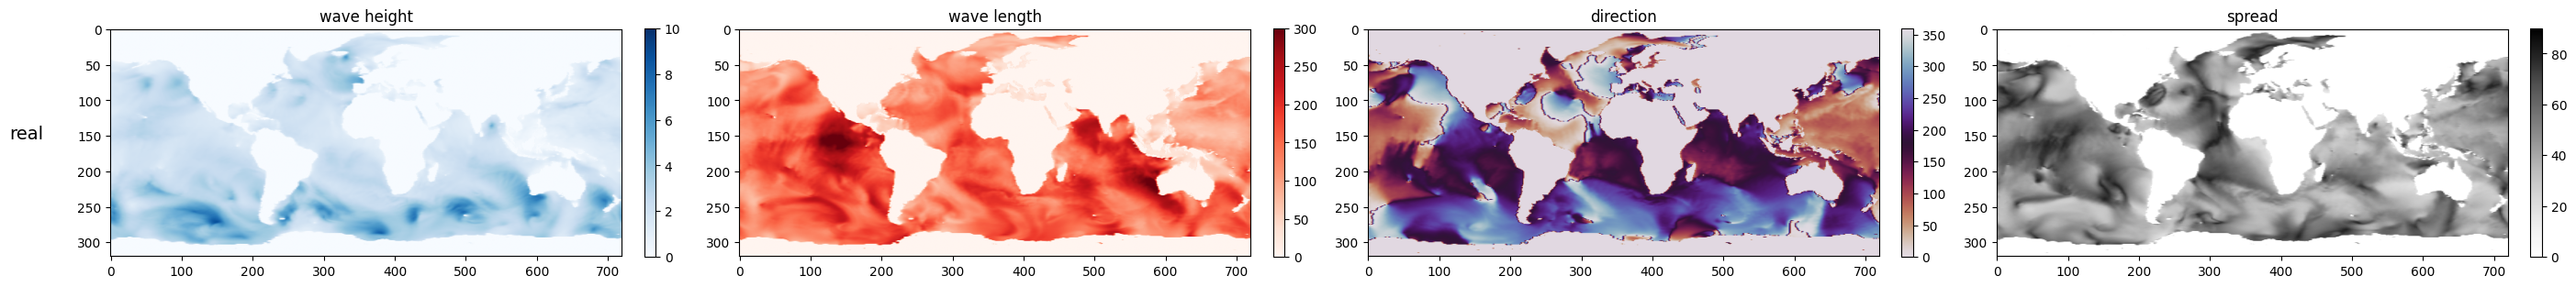

In [30]:
from waveutils import plot_wave
fig = plot_wave(mean[:,::-1], label='mean')
fig = plot_wave(x_truth[:,::-1], label='real')

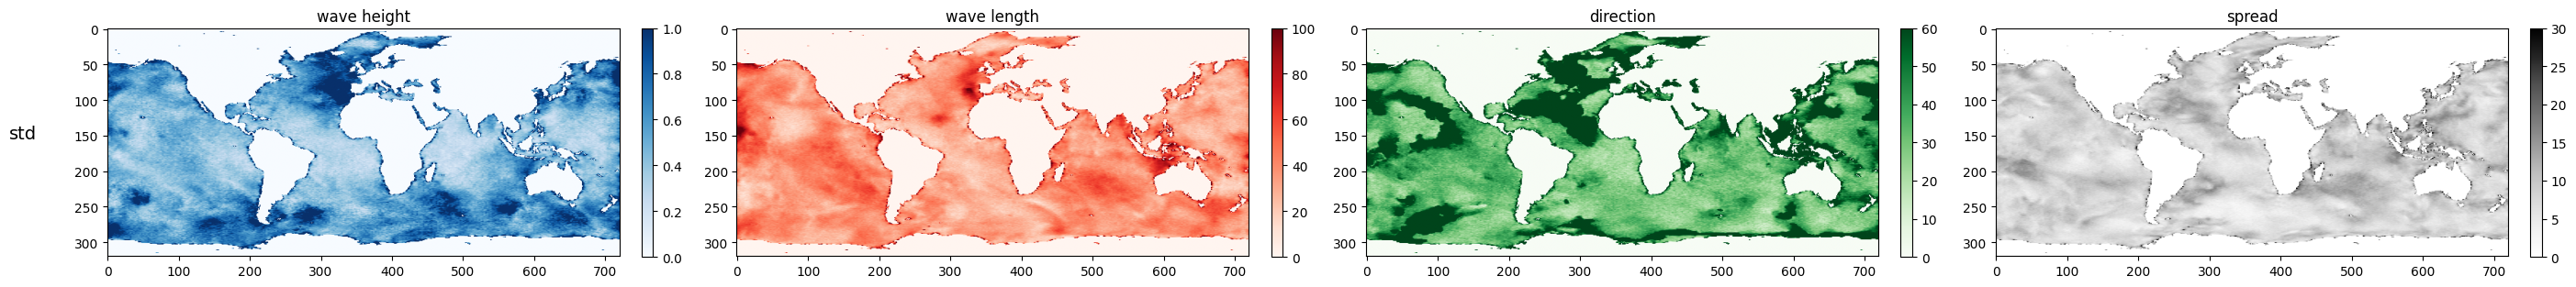

In [21]:
from matplotlib import pyplot as plt
def plot_var(x, label='None'):
    n_sample = x.shape[0]
    fig, axes = plt.subplots(1, 4, figsize=[30, 3], dpi=100)
    titles = ['wave height','wave length','direction','spread']
    imgs = [
        axes[0].imshow(x[0], vmin=0, vmax=1, cmap='Blues'),
        axes[1].imshow(x[1], vmin=0, vmax=100, cmap='Reds'),
        axes[2].imshow(x[2], vmin=0, vmax=60, cmap='Greens'),
        axes[3].imshow(x[3], vmin=0, vmax=30, cmap='Grays'),
    ]
    axes[0].set_ylabel(label, fontsize=14, rotation=0, labelpad=40)
    for j in range(4):
        axes[j].set_title(titles[j])
        fig.colorbar(imgs[j], ax=axes[j], fraction=0.046, pad=0.04)
        
    plt.tight_layout(rect=[0.06, 0, 1, 1])  # leave room on the left for text
    return fig

fig = plot_var(std[:,::-1], label='std')

### Plot distribution

(1, 320, 720)
(1, 320, 720)
(1, 320, 720)
(1, 320, 720)
(320, 720)
(320, 720)
(320, 720)
(320, 720)


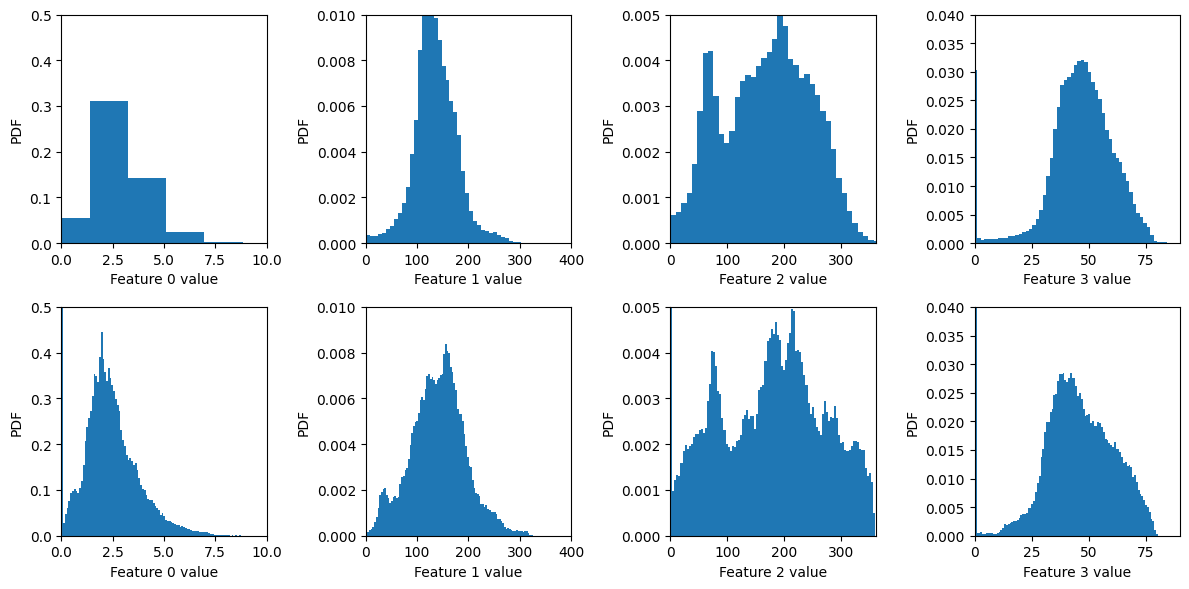

In [35]:
mask_bool = tf.Resize((320,720))(mask[0].to(x)).bool()[0]  # (H, W)

from matplotlib import pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=[12,6], dpi=100)
for i in range(0,4):
    feat_vals = x0_ensem[:, i]         # (B, H, W)
    print(feat_vals.shape)
    selected = feat_vals[:, mask_bool] # (B, Nmasked)
    selected = selected.reshape(-1)    # (B * Nmasked,)
    axes[0,i].hist(selected, bins=100, density=True)
    axes[0,i].set_xlabel(f"Feature {i} value")
    axes[0,i].set_ylabel("PDF")
    # axes[0,i].set_xlim([-3,3])

for i in range(0,4):
    feat_vals = x_truth[i]            # (H, W)
    print(feat_vals.shape)
    selected = feat_vals[mask_bool]
    axes[1,i].hist(selected, bins=100, density=True)
    axes[1,i].set_xlabel(f"Feature {i} value")
    axes[1,i].set_ylabel("PDF")
    # axes[1,i].set_xlim([-3,3])

axes[0,0].set_xlim([0,10]); axes[1,0].set_xlim([0,10])
axes[0,0].set_ylim([0,0.5]); axes[1,0].set_ylim([0,0.5])
axes[0,1].set_xlim([0,400]); axes[1,1].set_xlim([0,400])
axes[0,1].set_ylim([0,0.01]); axes[1,1].set_ylim([0,0.01])
axes[0,2].set_xlim([0,360]); axes[1,2].set_xlim([0,360])
axes[0,2].set_ylim([0,0.005]); axes[1,2].set_ylim([0,0.005])
axes[0,3].set_xlim([0,90]); axes[1,3].set_xlim([0,90])
axes[0,3].set_ylim([0,0.04]); axes[1,3].set_ylim([0,0.04])
plt.tight_layout()

In [ ]:
# If i compare the distribution of any generated field with the truth, it's ok.
# If i compare ensemble, distribution looks smoothed.
# But it seems that there are some extreme values for wave height
# print(x0_ensem[:,0].max()) gives about 340